In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

SYMBOL = "FRXAUDJPY"

if SYMBOL.upper().endswith("USDT") or SYMBOL.upper().endswith("BTC"):
    SYMBOL_TYPE = "binance"
elif SYMBOL.upper().startswith("FRX") or any(
    SYMBOL.upper().startswith(p) for p in
    ["R_", "1HZ", "BOOM", "CRASH", "JD", "WLD", "CRY"]
):
    SYMBOL_TYPE = "deriv"
else:
    SYMBOL_TYPE = "binance"

if SYMBOL_TYPE == "deriv":
    TIMEFRAME_ORDER = ["1d", "4h", "1h"]
else:
    TIMEFRAME_ORDER = ["4h", "1h", "15m", "5m"]

FILTER_CONFIG = {
    "use_parent_relative_filter": True,
    "min_impulse_parent_ratio":   0.10,
    "use_momentum_filter":        True,
    "min_momentum_ratio":         0.3,
    "use_dominance_filter":       True,
    "min_dominance_ratio":        1.0,
}

MAX_DEPTH = 3
MIN_INTERNAL_LEGS = 3

BOS_COLORS = {
    "true":    "#00C853",
    "false":   "#D50000",
    "pending": "#9E9E9E",
    "broken":  "#000000",
}
BOS_STYLES = {
    "true":    "-",
    "false":   "-",
    "pending": "--",
    "broken":  "-",
}
LAYER_COLORS = {
    1: "#2196F3",
    2: "#4CAF50",
    3: "#9C27B0",
    4: "#FF9800",
}

print(f"Symbol: {SYMBOL} | Type: {SYMBOL_TYPE} | TFs: {TIMEFRAME_ORDER}")

Symbol: FRXAUDJPY | Type: deriv | TFs: ['1d', '4h', '1h']


In [2]:
import yaml
import django
import os
os.chdir('..')

from src.db.session import SessionLocal
from src.cache.candle_store import get_candles
from src.core.trend_id import identify_trend, compute_internal_structure
from src.core.structural_walker import walk_structure, serialize_state_report

with open(ROOT / "config" / "timeframe_windows.yaml") as f:
    tf_cfg = yaml.safe_load(f)["timeframes"]

db = SessionLocal()

tf_results = {}

for tf in TIMEFRAME_ORDER:
    try:
        candles = get_candles(SYMBOL, tf, db)
    except Exception as e:
        print(f"[SKIP] {tf}: fetch failed - {e}")
        continue

    if not candles:
        print(f"[SKIP] {tf}: no candles in database")
        continue

    # Apply lookback filter if needed
    if tf in tf_cfg:
        lookback_days = tf_cfg[tf]["lookback_days"]
        from datetime import datetime, timedelta, timezone
        start_time = datetime.now(timezone.utc) - timedelta(days=lookback_days)
        candles = [c for c in candles if c.timestamp >= start_time]

    if not candles:
        print(f"[SKIP] {tf}: no candles after lookback filter")
        continue

    # Rest of the existing logic stays exactly the same
    result = identify_trend(candles, **FILTER_CONFIG)
    compute_internal_structure(candles, result["legs"], **FILTER_CONFIG)

    state_report = walk_structure(
        candles, result, FILTER_CONFIG,
        max_depth=MAX_DEPTH,
        symbol=SYMBOL
    )

    tf_results[tf] = {
        "candles": candles,
        "result": result,
        "state_report": state_report,
        "serialized_state_report": serialize_state_report(state_report),
        "lookback_days": tf_cfg.get(tf, {}).get("lookback_days", 365),
    }

    confirmed = sum(1 for l in result["legs"] if l.get("confirmed"))
    print(
        f"[OK] {tf}: {len(candles)} candles | trend={result['trend']} | "
        f"confirmed_legs={confirmed} | "
        f"depth_reached={state_report.get('max_depth_reached', 0)} | "
        f"mitigations={state_report.get('total_mitigation_count', 0)}"
    )

db.close()

Hydrating Deriv active symbols cache
Hydrating Deriv active symbols cache


[OK] 1d: 266 candles | trend=up | confirmed_legs=2 | depth_reached=1 | mitigations=0
[OK] 4h: 1555 candles | trend=up | confirmed_legs=2 | depth_reached=1 | mitigations=0
[OK] 1h: 3460 candles | trend=up | confirmed_legs=2 | depth_reached=1 | mitigations=0


In [3]:
from src.core.trend_id import identify_trend, compute_internal_structure

def classify_bos_crossing(
    candles,
    bos_price: float,
    crossing_global_start: int,
    crossing_global_end: int,
    global_trend: str,
    symbol: str,
    symbol_type: str,
    filter_config: dict,
    tf_key: str,
) -> str:
    """
    Classify a BOS crossing as true, false, pending, or broken.

    Reflects CURRENT state - not state at time of crossing.

    Steps:
    1. Slice candles from crossing_global_end forward to current
    2. Try identify_trend with timeframe deepening to find structure beyond BOS
    3. Check if any confirmed leg has both start and end price beyond the BOS
    4. Check if price has returned below the BOS since the crossing
    """
    post_slice = candles[crossing_global_end:]
    if len(post_slice) < 3:
        return "broken"

    def has_structure_beyond_bos(result, bos_price, trend):
        for leg in result.get("legs", []):
            if not leg.get("confirmed"):
                continue
            if leg.get("type") != "impulse":
                continue
            sp = float(leg["start_price"])
            ep = float(leg.get("end_price") or 0)
            if trend == "down":
                if sp >= bos_price and ep >= bos_price:
                    return True
            else:
                if sp <= bos_price and ep <= bos_price:
                    return True
        return False

    def price_returned_below_bos(post_slice, bos_price, trend):
        for c in post_slice:
            if trend == "down":
                if c.low < bos_price:
                    return True
            else:
                if c.high > bos_price:
                    return True
        return False

    post_result = identify_trend(post_slice, **filter_config)
    compute_internal_structure(post_slice, post_result["legs"], **filter_config)
    structure_found = has_structure_beyond_bos(post_result, bos_price, global_trend)

    deeper_tfs = {
        "1d": ["4h", "1h", "30m"],
        "4h": ["1h", "30m"],
        "1h": ["30m"],
        "30m": [],
        "15m": ["5m"],
        "5m": [],
    }
    if not structure_found:
        start_ts = candles[crossing_global_end].timestamp
        end_ts = candles[-1].timestamp
        for deeper_tf in deeper_tfs.get(tf_key, []):
            try:
                if symbol_type == "binance":
                    deeper_candles = fetch_binance_ohlc_sync(
                        symbol, deeper_tf, start_time=start_ts
                    )
                else:
                    from src.adapters.deriv_data import fetch_deriv_ohlc_sync
                    deeper_candles = fetch_deriv_ohlc_sync(
                        symbol, deeper_tf, start_time=start_ts
                    )
                deeper_slice = [
                    c for c in deeper_candles
                    if start_ts <= c.timestamp <= end_ts
                ]
                if len(deeper_slice) < 10:
                    continue
                deeper_result = identify_trend(deeper_slice, **filter_config)
                compute_internal_structure(
                    deeper_slice, deeper_result["legs"], **filter_config
                )
                if has_structure_beyond_bos(deeper_result, bos_price, global_trend):
                    structure_found = True
                    break
            except Exception:
                continue

    returned = price_returned_below_bos(post_slice, bos_price, global_trend)

    if structure_found and not returned:
        return "true"
    elif returned:
        return "false"
    elif not structure_found and not returned:
        return "pending"
    else:
        return "broken"

BOS | price=113.96 | start=243 (2026-03-11 00:00:00+00:00) | end=265 (2026-04-10 00:00:00+00:00) | broken=True


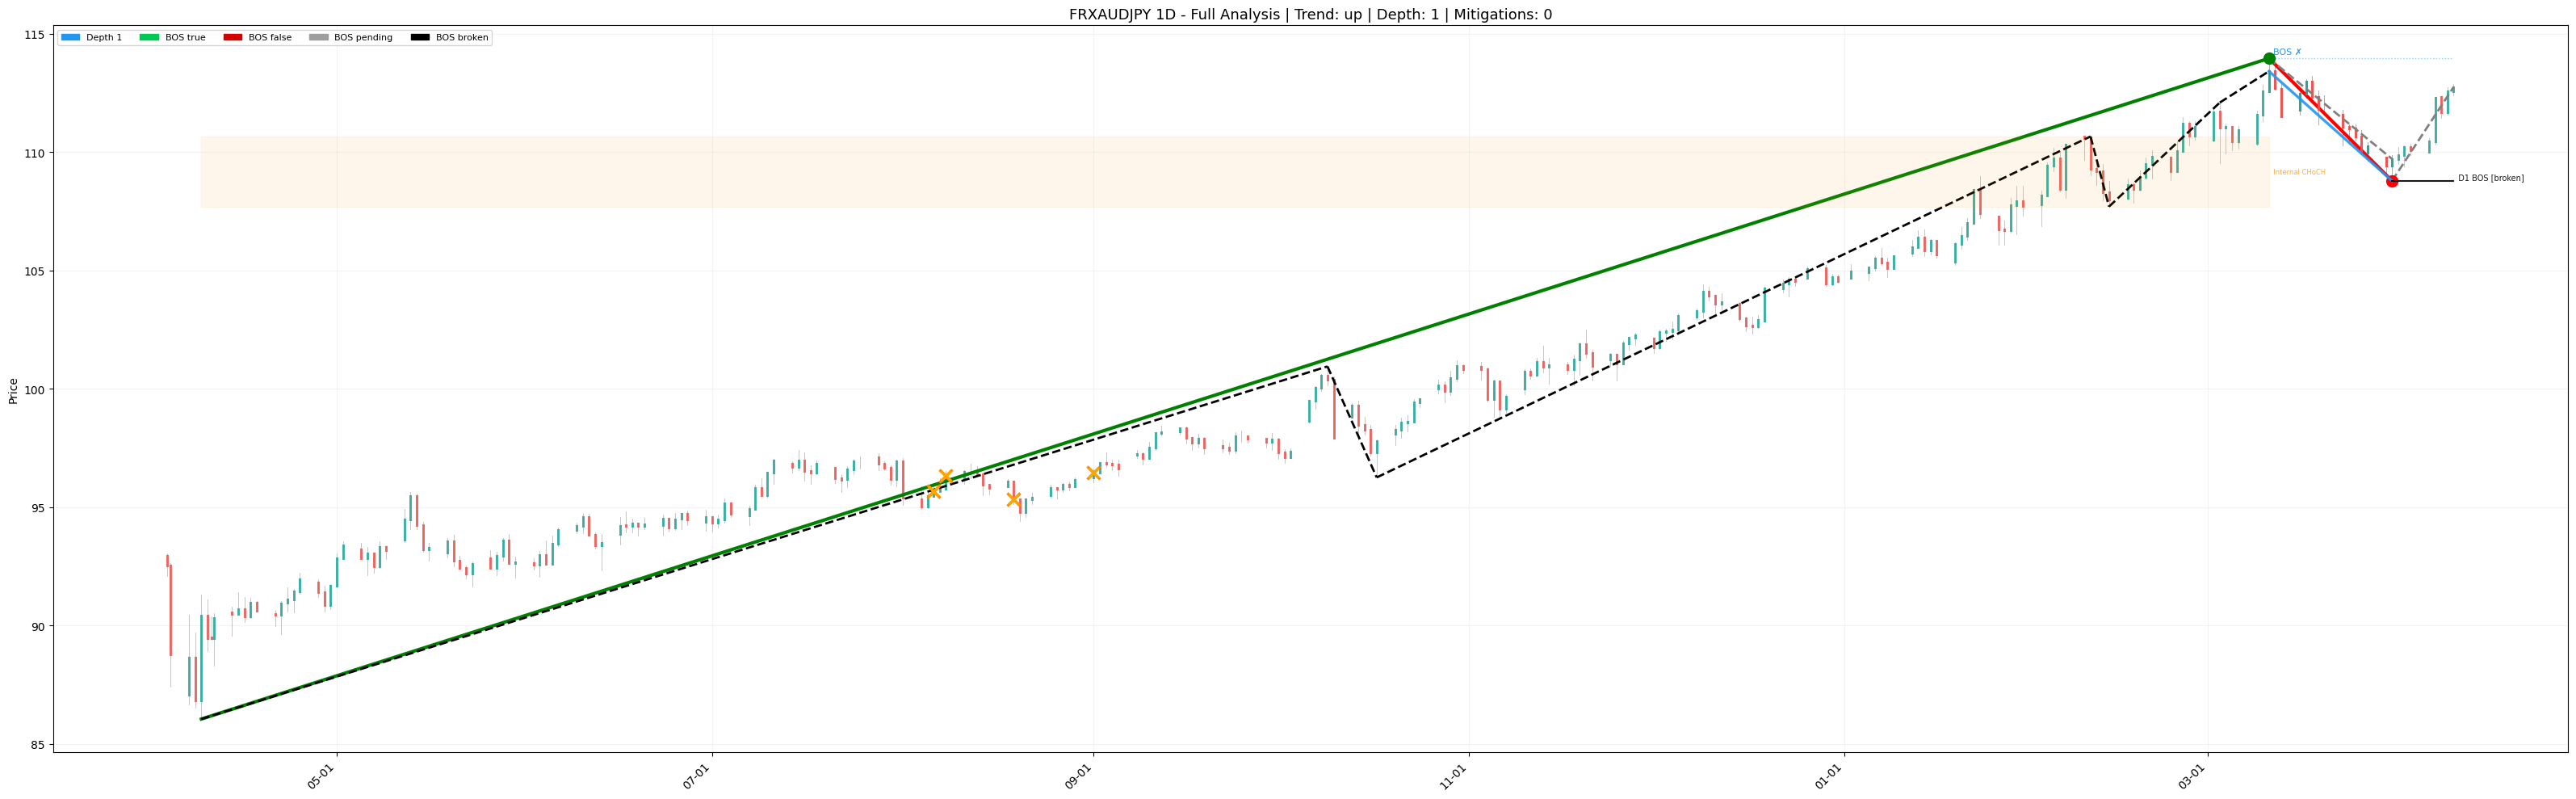


BOS | price=113.96 | start=1421 (2026-03-11 12:00:00+00:00) | end=1554 (2026-04-10 16:00:00+00:00) | broken=True
BOS | price=111.50 | start=14 (2026-03-13 20:00:00+00:00) | end=84 (2026-03-31 12:00:00+00:00) | broken=True
BOS | price=110.28 | start=47 (2026-03-23 08:00:00+00:00) | end=84 (2026-03-31 12:00:00+00:00) | broken=True
BOS | price=109.05 | start=78 (2026-03-30 12:00:00+00:00) | end=84 (2026-03-31 12:00:00+00:00) | broken=True


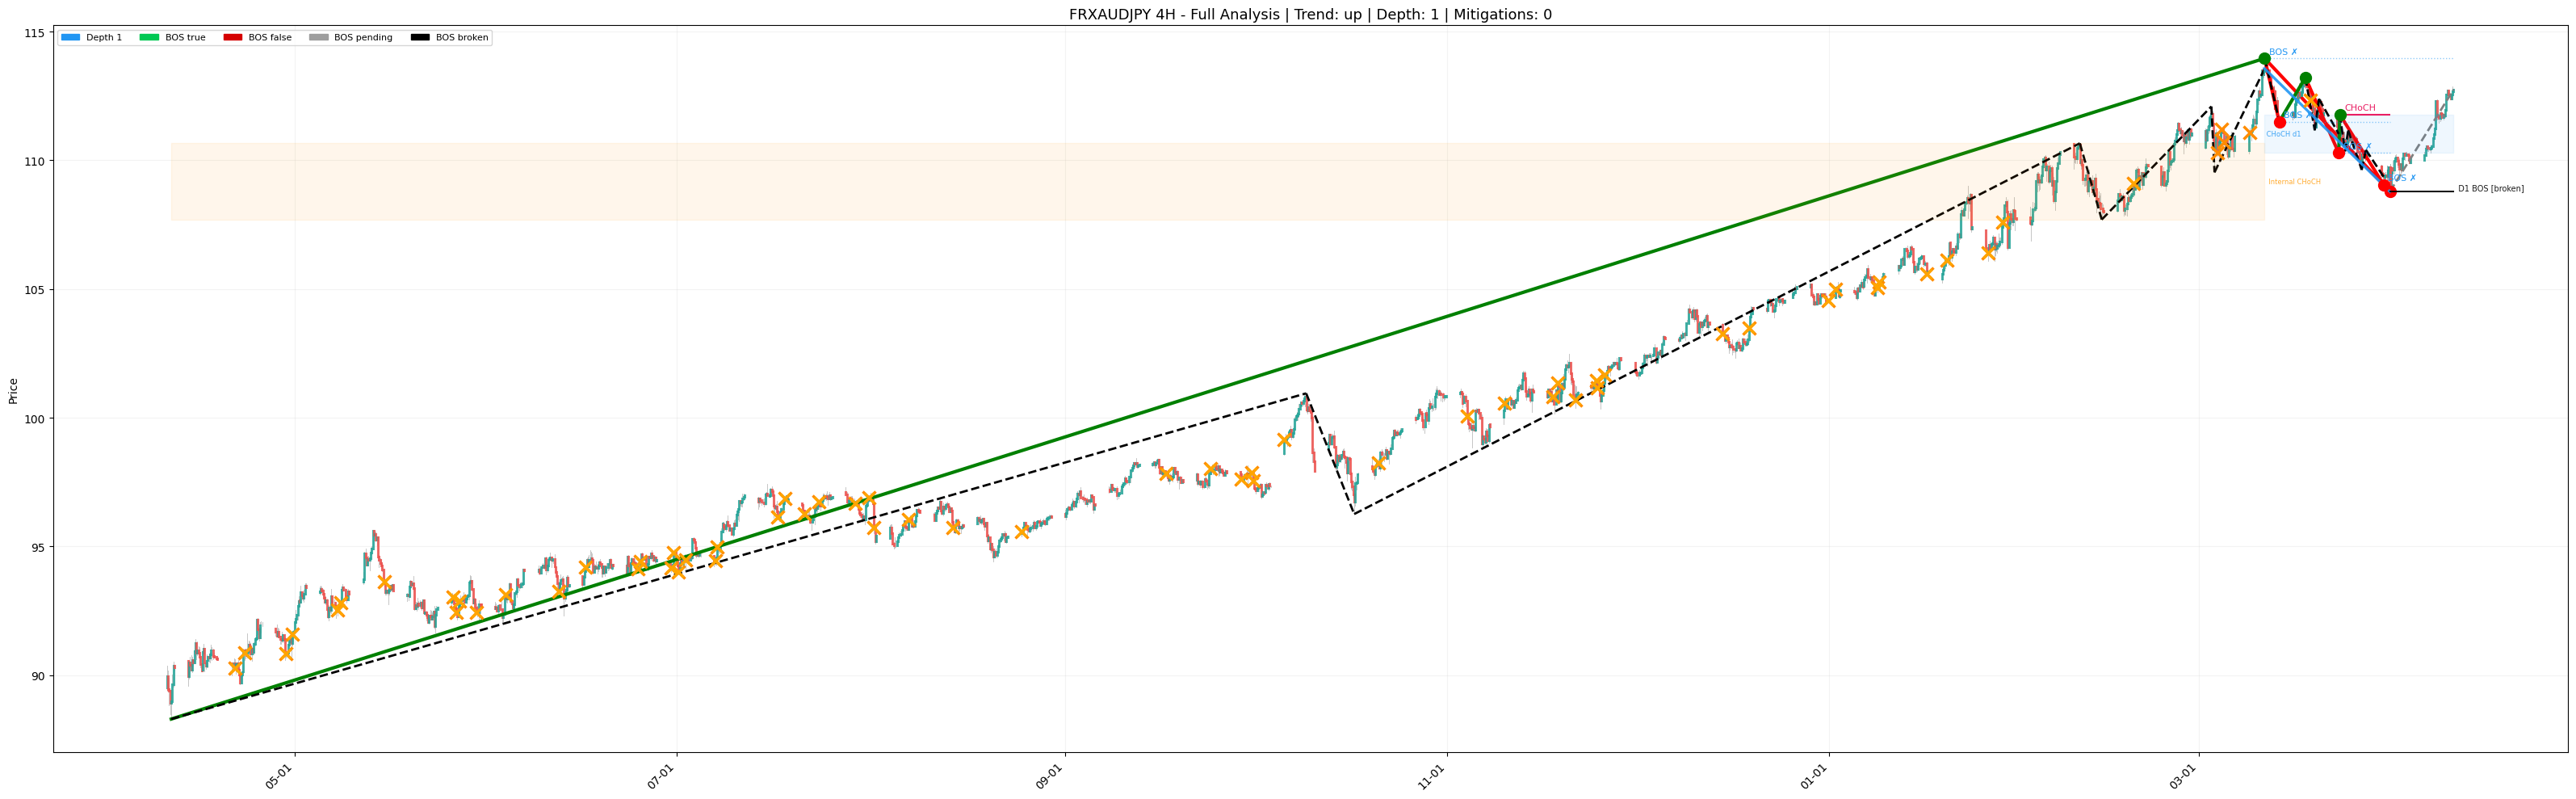


BOS | price=113.96 | start=2938 (2026-03-11 15:00:00+00:00) | end=3459 (2026-04-10 19:00:00+00:00) | broken=True
BOS | price=111.50 | start=54 (2026-03-13 20:00:00+00:00) | end=327 (2026-03-31 14:00:00+00:00) | broken=True
BOS | price=110.28 | start=182 (2026-03-23 10:00:00+00:00) | end=327 (2026-03-31 14:00:00+00:00) | broken=True
BOS | price=109.05 | start=303 (2026-03-30 14:00:00+00:00) | end=327 (2026-03-31 14:00:00+00:00) | broken=True


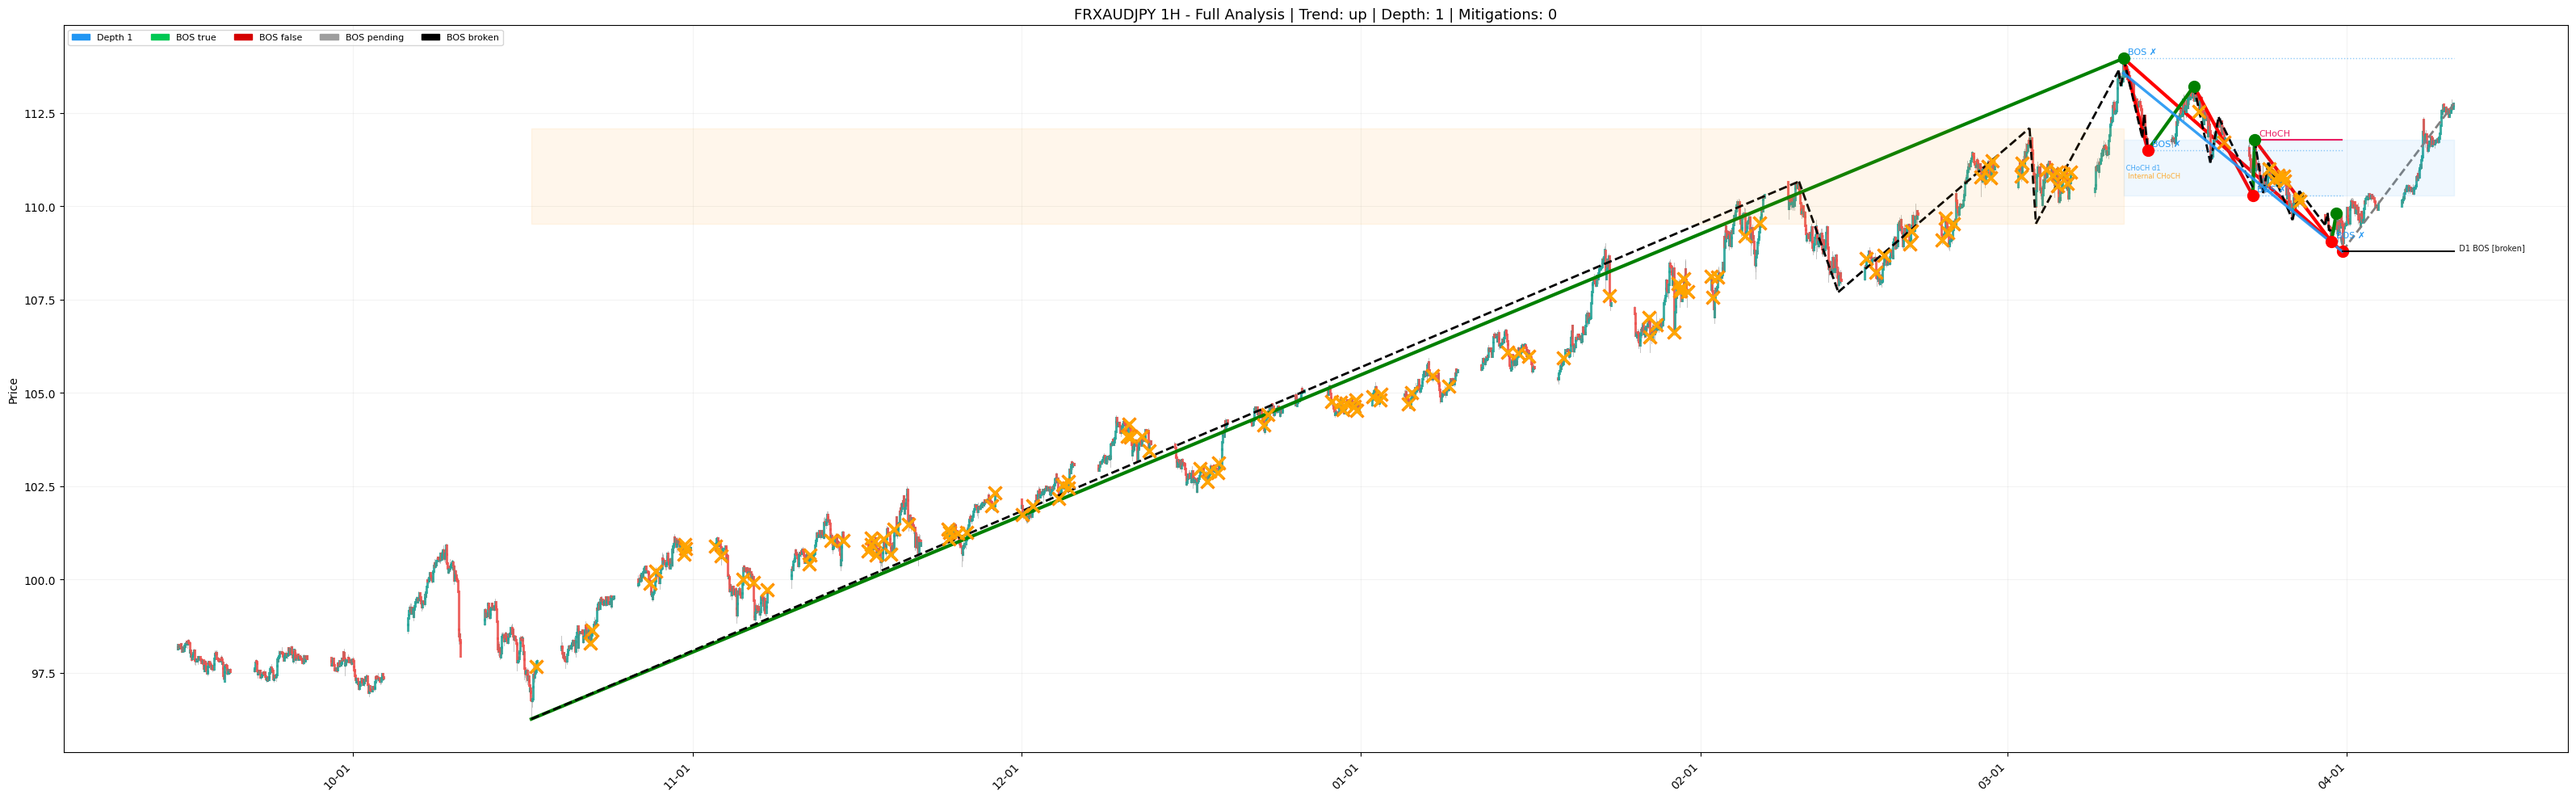

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from src.visualization.trend_chart import draw_trend_chart as _draw_trend_chart
from src.core.choch_zone import get_active_choch_zone

for tf, data in tf_results.items():
    candles = data["candles"]
    result = data["result"]
    state_report = data["state_report"]

    fig, ax = plt.subplots(figsize=(32, 10))

    # -- Layer 1: Global trend via draw_trend_chart -------------------------
    _draw_trend_chart(
        candles, result,
        title=f"{SYMBOL} {tf.upper()} - Full Analysis",
        use_datetime_axis=True,
        ax=ax,
    )

    # -- Layer 1b: CHoCH zone of internal structure for each global impulse --
    for leg in result["legs"]:
        if not leg.get("confirmed") or leg.get("type") != "impulse":
            continue
        if leg.get("end_index") is None:
            continue
        internal = leg.get("internal_structure")
        if internal is None:
            continue
        confirmed_internal = [l for l in internal.get("legs", []) if l.get("confirmed")]
        if len(confirmed_internal) < MIN_INTERNAL_LEGS:
            continue
        p_start = int(leg["start_index"])
        p_end = int(leg["end_index"])
        i_candles = candles[p_start : p_end + 1]
        choch_r = get_active_choch_zone(
            internal["legs"], internal["trend"], i_candles
        )
        if choch_r and choch_r.get("choch_zone"):
            zone = choch_r["choch_zone"]
            lower = float(zone["lower_boundary"])
            upper = float(zone["upper_boundary"])
            ts_s = candles[p_start].timestamp
            ts_e = candles[p_end].timestamp
            ax.fill_between(
                [ts_s, ts_e], lower, upper,
                alpha=0.08, color="#FF9800", zorder=2
            )
            ax.text(
                ts_e, (lower + upper) / 2,
                "  Internal CHoCH",
                color="#FF9800", fontsize=6, ha="left", va="center", alpha=0.8
            )

    # -- Layer 2: Structural walk depth levels ------------------------------
    levels = state_report.get("levels", [])
    for level in levels:
        depth = level["depth"]
        color = LAYER_COLORS.get(depth, "#607D8B")
        g_start = level.get("first_impulse_global_start")
        g_end = level.get("first_impulse_global_end")
        first_imp = level.get("first_impulse")
        struct_lvl = level.get("structural_level")
        choch_zone = level.get("choch_zone")
        first_move_candles = level.get("first_move_candles")
        int_result = level.get("internal_result")

        if first_imp and g_start is not None and g_end is not None:
            ax.plot(
                [candles[g_start].timestamp, candles[g_end].timestamp],
                [float(first_imp["start_price"]), float(first_imp["end_price"])],
                color=color, linewidth=2.4, linestyle="-",
                alpha=0.9, zorder=4 + depth, label=f"Depth {depth}"
            )

        if int_result is not None and first_move_candles is not None:
            _draw_trend_chart(
                first_move_candles, int_result,
                title="", use_datetime_axis=True, ax=ax
            )

        drawn_choch = choch_zone
        if drawn_choch is None and int_result is not None:
            rets = [
                l for l in int_result.get("legs", [])
                if l.get("type") == "retracement"
                and l.get("confirmed")
                and l.get("start_price") is not None
                and l.get("end_price") is not None
            ]
            if rets:
                lr = rets[-1]
                drawn_choch = {
                    "lower_boundary": min(float(lr["start_price"]), float(lr["end_price"])),
                    "upper_boundary": max(float(lr["start_price"]), float(lr["end_price"])),
                }
        if drawn_choch and g_start is not None:
            lower = float(drawn_choch["lower_boundary"])
            upper = float(drawn_choch["upper_boundary"])
            canvas_end = len(candles) - 1
            ax.fill_between(
                [candles[g_start].timestamp, candles[canvas_end].timestamp],
                lower, upper, alpha=0.07, color=color, zorder=2
            )
            ax.text(
                candles[g_start].timestamp, (lower + upper) / 2,
                f" CHoCH d{depth}",
                color=color, fontsize=6, ha="left", va="center", alpha=0.85
            )

        # -- Layer 3: BOS classification ------------------------------------
        if struct_lvl and g_end is not None:
            bos_price = float(struct_lvl["price"])
            crossing = level.get("crossing_attempt")

            if crossing:
                g_cross_start = crossing.get("global_start_index")
                g_cross_end = crossing.get("global_end_index")
                if g_cross_start is not None and g_cross_end is not None:
                    break_type = classify_bos_crossing(
                        candles=candles,
                        bos_price=bos_price,
                        crossing_global_start=g_cross_start,
                        crossing_global_end=g_cross_end,
                        global_trend=result["trend"],
                        symbol=SYMBOL,
                        symbol_type=SYMBOL_TYPE,
                        filter_config=FILTER_CONFIG,
                        tf_key=tf,
                    )
                else:
                    break_type = "broken"
            else:
                break_type = "broken"

            bos_color = BOS_COLORS[break_type]
            bos_style = BOS_STYLES[break_type]
            canvas_end = len(candles) - 1

            ax.plot(
                [candles[g_end].timestamp, candles[canvas_end].timestamp],
                [bos_price, bos_price],
                color=bos_color, linewidth=1.5,
                linestyle=bos_style, alpha=0.9, zorder=6
            )
            ax.text(
                candles[canvas_end].timestamp, bos_price,
                f"  D{depth} BOS [{break_type}]",
                color=bos_color, fontsize=7, ha="left", va="bottom", alpha=0.9
            )

    # -- Legend and formatting ---------------------------------------------
    legend_patches = []
    seen_depths = set()
    for level in levels:
        depth = level["depth"]
        if depth in seen_depths:
            continue
        seen_depths.add(depth)
        legend_patches.append(
            mpatches.Patch(color=LAYER_COLORS.get(depth, "#607D8B"), label=f"Depth {depth}")
        )
    for bt, bc in BOS_COLORS.items():
        legend_patches.append(mpatches.Patch(color=bc, label=f"BOS {bt}"))

    if legend_patches:
        ax.legend(
            handles=legend_patches, loc="upper left",
            ncol=max(1, min(len(legend_patches), 8)), fontsize=8
        )
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.15)
    ax.set_title(
        f"{SYMBOL} {tf.upper()} - Full Analysis | "
        f"Trend: {result['trend']} | "
        f"Depth: {state_report.get('max_depth_reached', 0)} | "
        f"Mitigations: {state_report.get('total_mitigation_count', 0)}",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()
    print()